In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

In [2]:

class SimpleAttention(tf.keras.layers.Layer):
    def __init__(self):
         # obligatoire
         super().__init__()
         # ici : définir les attributs self.S, self.A, self.O (pour pouvoir les afficher...
         self.A=None
         self.O=None
         self.S=None
         
    def call(self, X):
     # recopier ici les calculs de l’étape précédente :
          S= X @ tf.transpose(X, perm=[0, 2, 1]) 
     # 2) A = ... (softmax ligne par ligne)
          A = tf.nn.softmax(S, axis=-1)
     
          O=A@X
          self.A=A
          self.O=O
          self.S=S
          return O
    
    def get_S(self):
     return self.S
    
    def get_A(self):
     return self.A
    
    def get_O(self):
     return self.O
#X = np.random.randn(10, 8)
#layer = SimpleAttention()
#O = layer(X)

#print(f"Taille de X : {X.shape}")
#print(f"Taille de O : {O.shape}")
#print(f"Ligne 3 de A : {layer.get_A()[3]}")
#print(f"Somme ligne 3 : {np.sum(layer.get_A()[3])}")

In [3]:
vocab ={
    "the":0,"apothecary":1,"diaries":2, "pride":3, "and":4, "prejudice":5, "naruto":6,
    "jojo":7, "bizarre":8,"adventures":9,"is":10,"a":11,"anime":12,"novel":13,"your":14, "name":15,
    "one":16,"piece":17,"harry":18,"potter":19,"stranger":20,"an":21,"best":22,"?":23,"isn't":24,"it":25, "barrier":26,",":27,"of":28,

}
phrases=["the apothecary diaries is the best anime isn't it ?",
         "pride and prejudice is the best novel isn't it ?",
         "your name is jojo the stranger pride is your barrier ",
         "jojo bizarre adventures is the best anime isn't it ?",
         "one piece is the best anime , isn't it ?",
         "the stranger is the best novel , isn't it ?",
         "harry potter is the best novel , isn't it ?",
         "the apothecary barrier is one piece , isn't it ?",
         "naruto is one of the best anime isn't it ?",
         "your name is one of the best anime isn't it "]
#label choisi : anime
y = [1, 0, 0, 1, 1, 0, 0, 0, 1, 1]
def tokeniser(phrase,vocab):
    mots=phrase.split()
    return [vocab[mot] for mot in mots]
X=[tokeniser(phrase,vocab) for phrase in phrases]
#print(X)
X_train = X[:8]   
y_train = y[:8]

X_test = X[8:]    
y_test = y[8:]

In [57]:
input = tf.keras.layers.Input(shape=(10,))
X=tf.keras.layers.Embedding(29,10)(input)
x = SimpleAttention()(X)
x = tf.keras.layers.GlobalAveragePooling1D()(x) 
x = tf.keras.layers.Dense(1, activation='sigmoid')(x) 

model = tf.keras.Model(inputs=input, outputs=x)


model.compile(
    optimizer=Adam(learning_rate=1e-2),
    loss='binary_crossentropy',
    metrics=['accuracy']
)




In [58]:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=2,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.3750 - loss: 0.6932 - val_accuracy: 0.0000e+00 - val_loss: 0.6947
Epoch 2/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6250 - loss: 0.6826 - val_accuracy: 0.0000e+00 - val_loss: 0.7187
Epoch 3/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6250 - loss: 0.6596 - val_accuracy: 0.0000e+00 - val_loss: 0.7256
Epoch 4/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6250 - loss: 0.6403 - val_accuracy: 0.0000e+00 - val_loss: 0.7362
Epoch 5/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6250 - loss: 0.6224 - val_accuracy: 0.0000e+00 - val_loss: 0.7542
Epoch 6/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7500 - loss: 0.5949 - val_accuracy: 0.0000e+00 - val_loss: 0.7579
Epoch 7/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7500 - loss: 0.5704 - val_accuracy: 0.0000e+00 - val_loss: 0.7608
Epoch 8/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7500 - loss: 0.5405 - val_accuracy: 0.0000

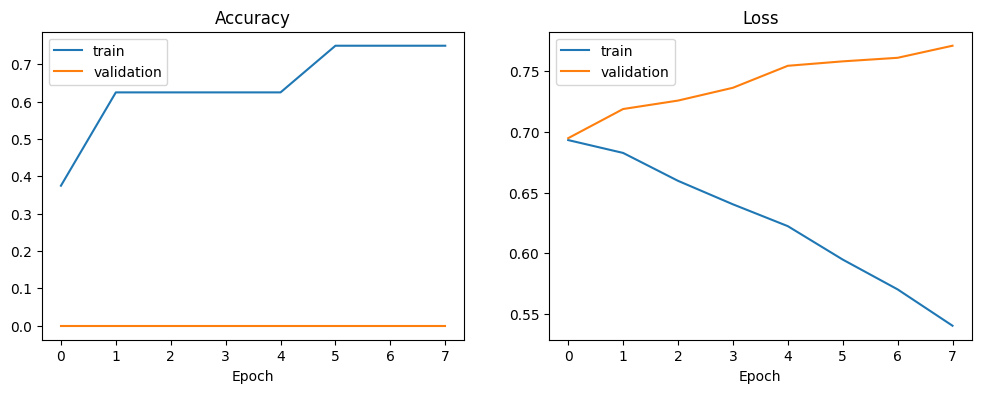

In [59]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Courbe Accuracy
ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Courbe Loss
ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

In [61]:

phrases_test = [
    "barrier is one of the best anime isn't it ?",  
    "the apothecary diaries is the best anime isn't it ?", 
]

for phrase in phrases_test:
    tokens = np.array([tokeniser(phrase, vocab)])
    prediction = model.predict(tokens, verbose=0)
    label = "anime " if prediction[0][0] > 0.5 else "pas anime "
    print(f"{phrase}")
    print(f"Prédiction : {prediction[0][0]:.4f} → {label}\n")


model.summary()

barrier is one of the best anime isn't it ?
Prédiction : 0.4574 → pas anime 

the apothecary diaries is the best anime isn't it ?
Prédiction : 0.4995 → pas anime 



Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_8 (Embedding)         │ (None, 10, 10)         │           290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_attention_8              │ (None, 10, 10)         │             0 │
│ (SimpleAttention)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 10)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 905 (3.54 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 604 (2.36 KB)